<a href="https://colab.research.google.com/github/depeshsikarwar/Data-Science/blob/main/lec11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  IMPORT LIBRERIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df=pd.read_excel("financial_loan.xlsx")
display(df.head())

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [18]:
# Meta Data
df=pd.read_excel("financial_loan.xlsx")
# df.info()
# print(df.shape)
# df.describe()
# df['application_type'].value_counts()
nfa=df['id'].nunique()
print(nfa)


38576


In [27]:
df=pd.read_excel("financial_loan.xlsx")
# num_app_in_current_date=df[df['issue_date'].dt.month==6]
current_date=pd.Timestamp.today()
current_month=current_date.month
current_till=current_date.day
print(current_date)
# current_month=current_date.month
print(current_till)
num_app_in_current_date=df[(df['issue_date'].dt.month==current_month) & (df['issue_date'].dt.day<=current_till)]
numapp=num_app_in_current_date['id'].nunique()
print(numapp)

2026-06-22 05:02:04.841704
22
3184


In [38]:
current_date=pd.Timestamp.today()
current_month=current_date.month
current_till=current_date.day
num_app_current_date=df[(df['issue_date'].dt.month==current_month) & (df['issue_date'].dt.day<=current_till)]
print(num_app_current_date['loan_amount'].sum())
print(f'Total MTD invested amount: ${round(num_app_current_date['loan_amount'].sum()/1000000,2)}M')

34161475
Total MTD invested amount: $34.16M


In [46]:
Good_Loan=df.groupby('loan_status')['loan_status'].count()
Percentage_Good_Loan=((df.groupby('loan_status')['loan_status'].count())/(df['loan_status'].count()))*100
print(Good_Loan)
print()
print(Percentage_Good_Loan)
print()
print(df.groupby('loan_status')['loan_amount'].sum())


loan_status
Charged Off     5333
Current         1098
Fully Paid     32145
Name: loan_status, dtype: int64

loan_status
Charged Off    13.824658
Current         2.846329
Fully Paid     83.329013
Name: loan_status, dtype: float64

loan_status
Charged Off     65532225
Current         18866500
Fully Paid     351358350
Name: loan_amount, dtype: int64


In [61]:
loan_status_data=df.groupby('loan_status').agg({
    'id':'count',
    'dti':'mean',
    'int_rate':'mean',
    'loan_amount':'sum',
  'total_payment':'sum'
})
# print(loan_status_data)
loan_status_data.rename(columns= {'id':'Number of Application'},inplace=True)
display(loan_status_data)
Percentage_Good_Loan=((df.groupby('loan_status')['loan_status'].count())/(df['loan_status'].count()))*100
print(Percentage_Good_Loan)




,Number of Application,dti,int_rate,loan_amount,total_payment
loan_status,,,,,
Charged Off,5333,0.140047,0.138786,65532225,37284763
Current,1098,0.147243,0.150993,18866500,24199914
Fully Paid,32145,0.131674,0.116411,351358350,411586256


loan_status
Charged Off    13.824658
Current         2.846329
Fully Paid     83.329013
Name: loan_status, dtype: float64


In [66]:
# Good Loan Analysis
# Number of Application
no_of_application=loan_status_data.loc["Current","Number of Application"]+loan_status_data.loc["Fully Paid","Number of Application"]
print(no_of_application)

# Funded Amount
funded_amount=loan_status_data.loc["Current","loan_amount"]+loan_status_data.loc["Fully Paid","loan_amount"]
print(funded_amount)

# Average DTI
average_dti=loan_status_data.loc["Current","dti"]+loan_status_data.loc["Fully Paid","dti"]
print(average_dti)

# Received amount
received_amount=loan_status_data.loc["Current","total_payment"]+loan_status_data.loc["Fully Paid","total_payment"]
print(received_amount)

# Profit
print(received_amount-funded_amount)


33243
370224850
0.27891695016689233
435786170
65561320


In [68]:
# Bad Loan
# Number of application
no_of_application=loan_status_data.loc["Charged Off","Number of Application"]
print(no_of_application)

# Funded Amount
funded_amount=loan_status_data.loc["Charged Off","loan_amount"]
print(funded_amount)

# Received amount
received_amount=loan_status_data.loc["Charged Off","total_payment"]
print(received_amount)

# Profit
print(funded_amount-received_amount)


5333
65532225
37284763
28247462


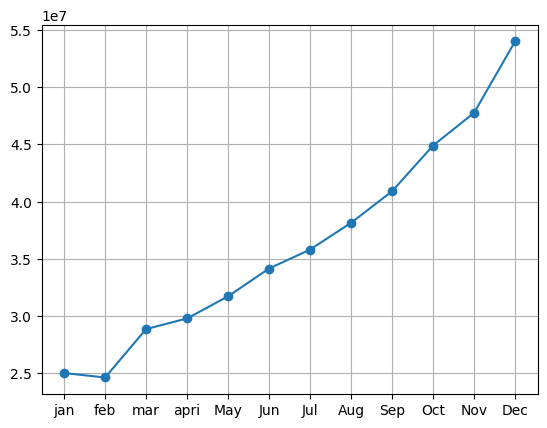

In [90]:

df["month"]=list(df["issue_date"].dt.month)
y=df.groupby( "month",as_index=False)["loan_amount"].sum()
months=['jan','feb','mar','apri','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.plot(months,y["loan_amount"],marker='o')
plt.grid()
plt.show()